## Importing dependencies

In [143]:
# ------------------------------
# Import Dependencies
# ------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report



# Data Collection and Processing

In [144]:
# Load Dataset
# ------------------------------
data_path = "./datasets/train_u6lujuX_CVtuZ9i (1).csv"
df = pd.read_csv(data_path)

# Preview dataset
print("First 5 rows:\n", df.head())
print("Shape of dataset:", df.shape)
print("Statistical Summary:\n", df.describe())



First 5 rows:
     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2    

In [145]:

# ------------------------------
# Data Cleaning
# ------------------------------

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with missing values
df.dropna(inplace=True)
print("After dropping missing values:\n", df.isnull().sum())



Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
After dropping missing values:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [146]:
#number of rows and columns

# ------------------------------
# Label Encoding
# ------------------------------
# Convert target column 'Loan_Status' to numerical
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

# Replace '3+' in Dependents with 4 and convert column to numeric
df['Dependents'] = df['Dependents'].replace('3+', 4).astype(float)

# Map other categorical columns
categorical_mappings = {
    "Married": {"No": 0, "Yes": 1},
    "Education": {"Graduate": 1, "Not Graduate": 0},
    "Gender": {"Male": 1, "Female": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Property_Area": {"Rural": 0, "Urban": 1, "Semiurban": 2}
}
df.replace(categorical_mappings, inplace=True)



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,LP001006,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,LP001008,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,1,1
5,LP001011,1,1,2.0,1,1,5417,4196.0,267.0,360.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0.0,1,0,2900,0.0,71.0,360.0,1.0,0,1
610,LP002979,1,1,4.0,1,0,4106,0.0,40.0,180.0,1.0,0,1
611,LP002983,1,1,1.0,1,0,8072,240.0,253.0,360.0,1.0,1,1
612,LP002984,1,1,2.0,1,0,7583,0.0,187.0,360.0,1.0,1,1


In [147]:
# ------------------------------
# Explore Unique Values (optional)
# ------------------------------
for col in df.columns:
    print(f"Column: {col}, Unique values: {df[col].unique()}")
    print("-" * 50)



Column: Loan_ID, Unique values: <StringArray>
['LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011', 'LP001013',
 'LP001014', 'LP001018', 'LP001020', 'LP001024',
 ...
 'LP002958', 'LP002959', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 480, dtype: str
--------------------------------------------------
Column: Gender, Unique values: [1 0]
--------------------------------------------------
Column: Married, Unique values: [1 0]
--------------------------------------------------
Column: Dependents, Unique values: [1. 0. 2. 4.]
--------------------------------------------------
Column: Education, Unique values: [1 0]
--------------------------------------------------
Column: Self_Employed, Unique values: [0 1]
--------------------------------------------------
Column: ApplicantIncome, Unique values: [ 4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  3073  1853
  1299  4950  3510  4887  7660  5955  2600  9560  2799

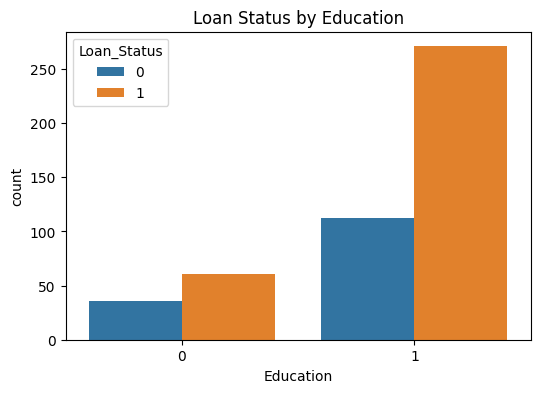

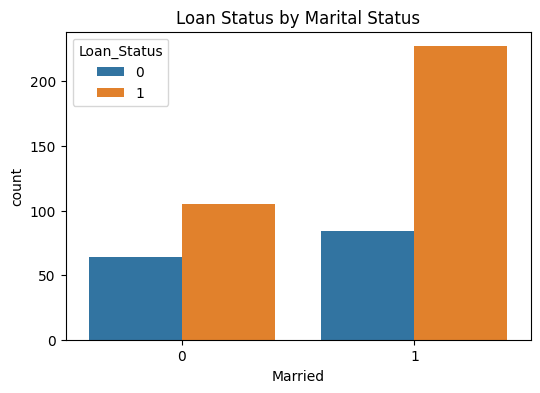

In [154]:

# ------------------------------
# Data Visualization (optional)
# ------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Loan Status by Education")
plt.savefig("images/loan_education.png",dpi=300,bbox_inches="tight") 

plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Married", hue="Loan_Status", data=df)
plt.title("Loan Status by Marital Status")
plt.savefig("images/loan_married.png",dpi=300,bbox_inches="tight") 
    
plt.show()



In [149]:

# ------------------------------
# Prepare Features and Target
# ------------------------------
X = df.drop(columns=["Loan_ID", "Loan_Status"]).astype(float)
y = df["Loan_Status"].astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)



In [102]:
load_dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [150]:
# ------------------------------
# Feature Scaling
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [104]:
#dependant columns 
load_dataset["Dependents"].value_counts()


Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [151]:
# ------------------------------
# Model Training using SVM
# ------------------------------
model = SVC(kernel="linear", random_state=42)
model.fit(X_train_scaled, y_train)



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [152]:
# ------------------------------
# Predictions and Evaluation
# ------------------------------
# On Test set
y_pred_test = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Accuracy on Test Set: {test_accuracy:.2f}")

# On Train set
y_pred_train = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Accuracy on Train Set: {train_accuracy:.2f}")

# Detailed Classification Report
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test))

Accuracy on Test Set: 0.79
Accuracy on Train Set: 0.81

Classification Report (Test Set):

              precision    recall  f1-score   support

         0.0       0.86      0.40      0.55        15
         1.0       0.78      0.97      0.86        33

    accuracy                           0.79        48
   macro avg       0.82      0.68      0.71        48
weighted avg       0.80      0.79      0.77        48

